In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")

In [12]:
# Dataset A — Symmetric
dataset_A = np.random.normal(loc=50, scale=10, size=500)

# Dataset B — Right-skewed
dataset_B = np.random.exponential(scale=20, size=500)
dataset_B = dataset_B - dataset_B.min()
dataset_B = dataset_B / dataset_B.max() * 100

# Dataset C — Bimodal
dataset_C1 = np.random.normal(loc=30, scale=5, size=250)
dataset_C2 = np.random.normal(loc=70, scale=5, size=250)
dataset_C = np.concatenate([dataset_C1, dataset_C2])

In [15]:
def summarize_dataset(data):
    mean = np.mean(data)
    median = np.median(data)

    # Mode (safe for scipy versions)
    mode_result = stats.mode(np.round(data, 2), keepdims=True)
    mode_val = mode_result.mode[0]

    std = np.std(data, ddof=1)
    variance = np.var(data, ddof=1)
    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    skewness = stats.skew(data)
    kurtosis = stats.kurtosis(data)

    return {
        "Mean": round(mean, 2),
        "Median": round(median, 2),
        "Mode": round(mode_val, 2),
        "Standard Deviation": round(std, 2),
        "Variance": round(variance, 2),
        "IQR": round(iqr, 2),
        "Skewness": round(skewness, 2),
        "Kurtosis": round(kurtosis, 2)
    }

In [16]:
summary_table = pd.DataFrame({
    "Dataset A": summarize_dataset(dataset_A),
    "Dataset B": summarize_dataset(dataset_B),
    "Dataset C": summarize_dataset(dataset_C)
}).T

summary_table

,Mean,Median,Mode,Standard Deviation,Variance,IQR,Skewness,Kurtosis
Dataset A,50.07,50.13,34.85,9.81,96.29,13.37,0.18,0.26
Dataset B,16.17,11.29,0.14,15.99,255.64,18.65,1.77,3.98
Dataset C,50.33,49.53,24.89,20.30,412.02,39.01,0.01,-1.76


### Task 1: Observations

- Dataset A (symmetric) has mean and median very close, indicating a balanced distribution.
- Dataset B (right-skewed) shows a clear difference between mean and median, with mean greater than median due to the long right tail.
- Dataset C (bimodal) has mean and median near the center, but this hides the fact that the data has two distinct peaks.

- Standard deviation and variance differ across datasets, reflecting differences in spread.
- Skewness clearly distinguishes Dataset B as right-skewed, while Dataset A and C have skewness close to zero.
- Kurtosis highlights differences in tail behavior, especially for the skewed dataset.

Overall, mean and median can appear similar across datasets, but skewness and kurtosis reveal important differences in distribution shape.

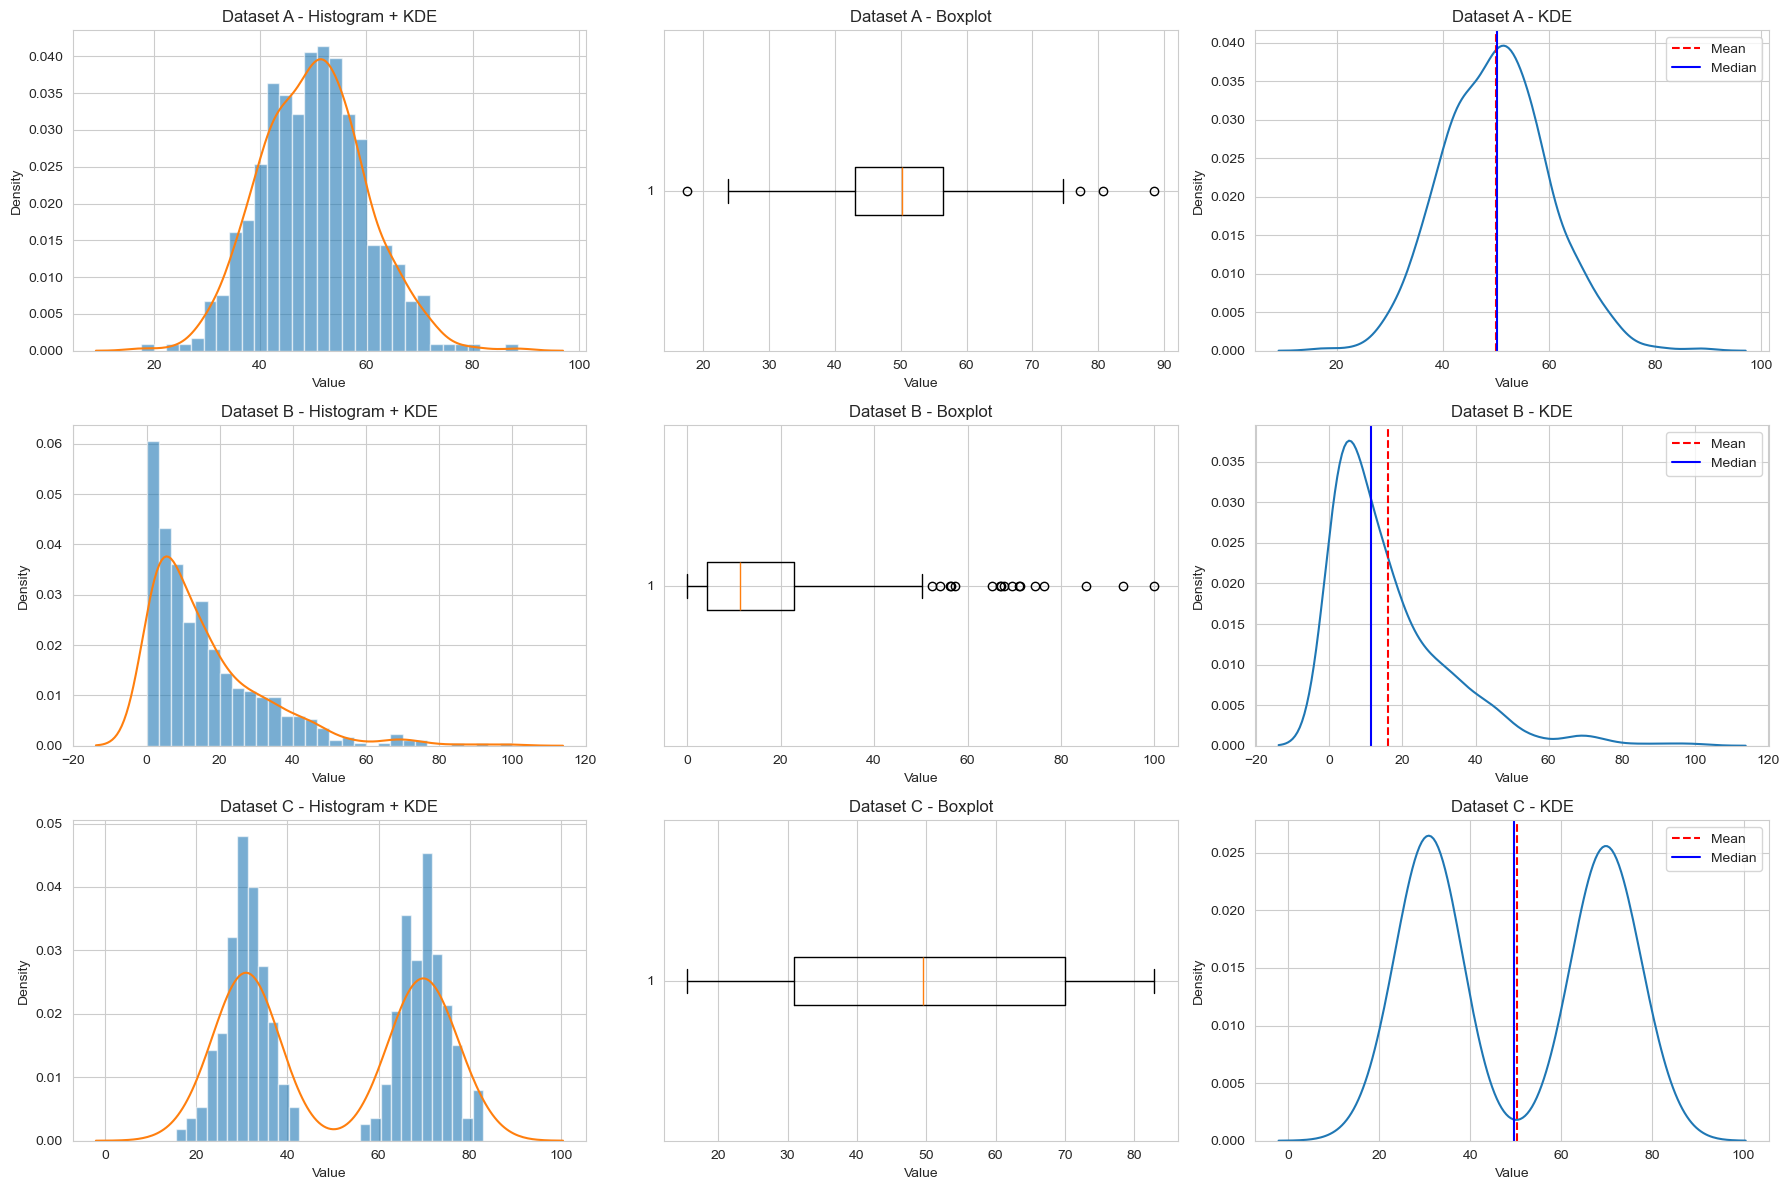

In [17]:
# Task 2: Visualize the Distributions

datasets = [dataset_A, dataset_B, dataset_C]
dataset_names = ["Dataset A", "Dataset B", "Dataset C"]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for i, data in enumerate(datasets):
    mean_val = np.mean(data)
    median_val = np.median(data)
    
    # 1. Histogram with 30 bins + KDE overlay
    axes[i, 0].hist(data, bins=30, density=True, alpha=0.6)
    sns.kdeplot(data, ax=axes[i, 0])
    axes[i, 0].set_title(f"{dataset_names[i]} - Histogram + KDE")
    axes[i, 0].set_xlabel("Value")
    axes[i, 0].set_ylabel("Density")

    # 2. Boxplot (horizontal)
    axes[i, 1].boxplot(data, vert=False)
    axes[i, 1].set_title(f"{dataset_names[i]} - Boxplot")
    axes[i, 1].set_xlabel("Value")

    # 3. KDE plot with mean and median lines
    sns.kdeplot(data, ax=axes[i, 2])
    axes[i, 2].axvline(mean_val, linestyle='--', color='red', label='Mean')
    axes[i, 2].axvline(median_val, linestyle='-', color='blue', label='Median')
    axes[i, 2].set_title(f"{dataset_names[i]} - KDE")
    axes[i, 2].set_xlabel("Value")
    axes[i, 2].set_ylabel("Density")
    axes[i, 2].legend()

plt.tight_layout()
plt.show()

### Task 2: Observations

- The largest divergence between the mean and median is observed in **Dataset B**.
- This dataset is right-skewed, where the mean is greater than the median.

- The divergence is caused by a **long right tail**, which pulls the mean toward higher values.
- In the histogram and KDE plot, this appears as an extended tail to the right.
- In the boxplot, the median is shifted toward the lower end of the box, and outliers extend to the right.

- In contrast, Dataset A shows minimal divergence due to its symmetric distribution.
- Dataset C appears symmetric overall, but its bimodal structure is not fully captured by mean and median alone.

In [18]:
# Create modified Dataset A with extreme outliers
dataset_A_modified = dataset_A.copy()

# Find indices of 5 largest values
top_5_idx = np.argsort(dataset_A_modified)[-5:]

# Multiply them by 10
dataset_A_modified[top_5_idx] = dataset_A_modified[top_5_idx] * 10

In [19]:
summary_outlier = pd.DataFrame({
    "Original A": summarize_dataset(dataset_A),
    "Modified A": summarize_dataset(dataset_A_modified)
}).T

summary_outlier

,Mean,Median,Mode,Standard Deviation,Variance,IQR,Skewness,Kurtosis
Original A,50.07,50.13,34.85,9.81,96.29,13.37,0.18,0.26
Modified A,57.17,50.13,34.85,74.38,5532.48,13.37,9.70,94.18


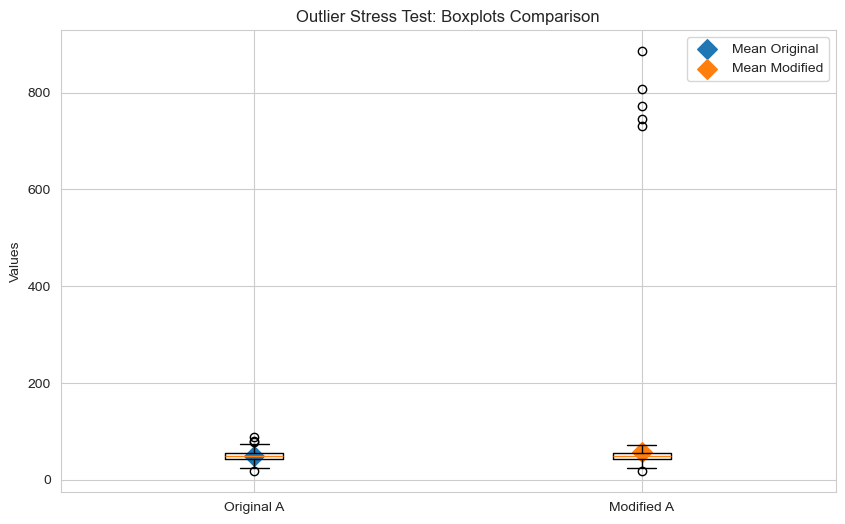

In [20]:
plt.figure(figsize=(10,6))

# Boxplots
plt.boxplot([dataset_A, dataset_A_modified], vert=True)

plt.xticks([1, 2], ["Original A", "Modified A"])
plt.title("Outlier Stress Test: Boxplots Comparison")
plt.ylabel("Values")

# Overlay mean as diamond marker
plt.scatter(1, np.mean(dataset_A), marker='D', s=100, label='Mean Original')
plt.scatter(2, np.mean(dataset_A_modified), marker='D', s=100, label='Mean Modified')

plt.legend()
plt.show()

### Task 3: Outlier Stress Test Observations

- The statistics that changed the most are **mean, standard deviation, variance, skewness, and kurtosis**.
- The mean increased significantly because it is sensitive to extreme values.
- Standard deviation and variance increased due to the larger spread caused by outliers.
- Skewness became strongly positive, indicating a long right tail.
- Kurtosis increased substantially, showing heavy tails and extreme values.

- The **median remained nearly unchanged**, making it a robust statistic.
- The **mode also remained relatively stable**.

- If reporting a "typical" value for the modified dataset, the **median should be used instead of the mean**.
- This is because the mean is heavily influenced by extreme outliers, while the median better represents the central tendency of the majority of the data.